# Import Libraries
- Statistical analysis (chi-square, t-tests, ANOVA)
- Distribution analysis (skewness, kurtosis)
- Multiple classification models (Logistic Regression, Random Forest)
- Comprehensive evaluation metrics

In [20]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import chi2_contingency, ttest_ind, norm, f_oneway, skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns


# Load Dataset and Feature Engineering
- Dataset: Titanic (titanic_toy.csv)
- Missing value imputation: Median for Age and Fare
- Features: Age, Fare, Family
- Target: Survived (binary classification)
- 80-20 train-test split

In [24]:
# Load dataset
file_path = './dataset/titanic_toy.csv'
data = pd.read_csv(file_path)

# Impute missing values with median for "Age" and "Fare"
imputer = SimpleImputer(strategy='median')
data['Age'] = imputer.fit_transform(data[['Age']])
data['Fare'] = imputer.fit_transform(data[['Fare']])

# Define Features and Target
X = data[['Age', 'Fare', 'Family']]
y = data['Survived']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Probability Theory - Bayes' Theorem Example
This appears to be a theoretical demonstration of Bayes' Theorem, separate from the Titanic dataset. It shows:
- Basic probability calculations
- Conditional probability: P(A|B)
- Bayes' Theorem application to find P(B|A)

In [16]:
# Example probabilities
P_A = 0.6  # Probability of Event A
P_B = 0.7  # Probability of Event B
P_A_given_B = 0.5  # Conditional Probability: P(A|B)

# Joint Probability using Bayes' Theorem
P_B_given_A = (P_A_given_B * P_B) / P_A
print(f"Probability of B given A: {P_B_given_A}")


Probability of B given A: 0.5833333333333334


# Probability Distributions - Normal Distribution Visualization
- Simulated normal distribution (μ=50, σ=10, n=1000)
- Histogram with KDE (Kernel Density Estimation) overlay
- Visual demonstration of the bell curve

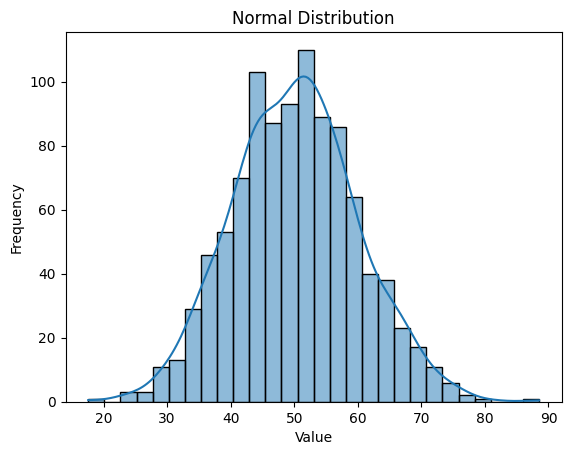

In [17]:
# Simulate a Normal Distribution
np.random.seed(42)
random_variable = np.random.normal(loc=50, scale=10, size=1000)

# Visualize the Probability Distribution
sns.histplot(random_variable, kde=True)
plt.title('Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()


# Descriptive Statistics - Age Analysis
- Central Tendency: Mean (29.36), Median (28.0), Mode (28.0)
- Dispersion: Range (79.58), Variance (169.51), Std Dev (13.02)
- Analysis on the Age feature from the Titanic dataset

In [18]:
mean_age = data['Age'].mean()
median_age = data['Age'].median()
mode_age = data['Age'].mode()[0]
range_age = data['Age'].max() - data['Age'].min()
variance_age = data['Age'].var()
std_dev_age = data['Age'].std()

print(f"Mean: {mean_age}, Median: {median_age}, Mode: {mode_age}")
print(f"Range: {range_age}, Variance: {variance_age}, Standard Deviation: {std_dev_age}")


Mean: 29.36158249158249, Median: 28.0, Mode: 28.0
Range: 79.58, Variance: 169.51249827942345, Standard Deviation: 13.019696550973201


# Distribution Shape Analysis - Skewness and Kurtosis
- Skewness: 0.509 (positive) → Right-skewed distribution (more older passengers)
-Kurtosis: 0.982 (positive) → Leptokurtic distribution (heavier tails, more peaked than normal)

In [ ]:
skewness_age = skew(data['Age'])
kurtosis_age = kurtosis(data['Age'])

print(f"Skewness: {skewness_age}, Kurtosis: {kurtosis_age}")


Skewness: 0.5093852558219663, Kurtosis: 0.9815760369363544


# Visualizing Age and Fare Distributions
- Age Distribution (Histogram + KDE): Confirms the right-skewed distribution (skewness=0.509), most passengers between 20-40 years
- Fare Distribution (Box Plot): Shows extreme outliers (one fare ~512), indicating high-class passengers, most fares are low

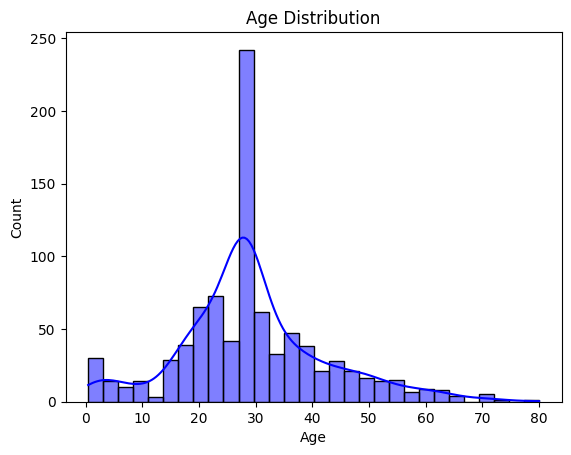

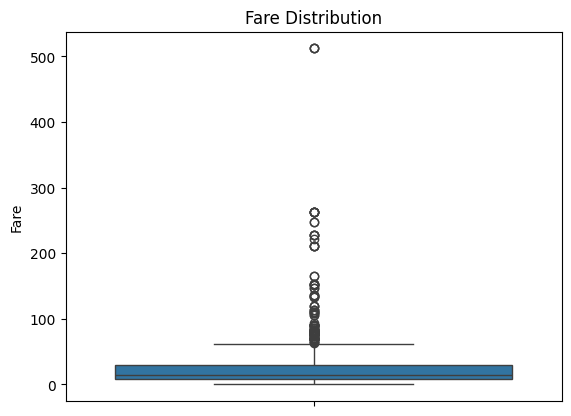

In [22]:
# Histogram
sns.histplot(data['Age'], kde=True, color='blue')
plt.title('Age Distribution')
plt.show()

# Box Plot
sns.boxplot(data['Fare'])
plt.title('Fare Distribution')
plt.show()


# Statistical Inference - Confidence Interval Calculation
- Sample: From the simulated normal distribution (μ=50, σ=10)
- 95% Confidence Interval: (49.59, 50.80)
- Interpretation: We're 95% confident the true population mean lies within this range
- Uses Z-score for large sample (n=1000)

In [23]:
sample_mean = np.mean(random_variable)
sample_std = np.std(random_variable, ddof=1)
confidence_level = 0.95
z_score = norm.ppf((1 + confidence_level) / 2)
margin_of_error = z_score * (sample_std / np.sqrt(len(random_variable)))

lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error
print(f"95% Confidence Interval: ({lower_bound}, {upper_bound})")


95% Confidence Interval: (49.586407384186046, 50.800233732260466)


# Feature-Target Relationship Analysis (Chi-Square Test)
- Test: Chi-Square test for independence between Family and Survived
- Chi-Square Statistic: 80.67
- P-value: 3.58e-14 (highly significant, p < 0.05)
- Conclusion: Strong statistical evidence that Family size significantly affects survival

In [3]:
# Chi-square test for "Family" and "Survived"
contingency_table = pd.crosstab(data['Family'], data['Survived'])
chi2_stat, p_value_chi2, _, _ = chi2_contingency(contingency_table)
print(f"Chi-Square Test: Stat={chi2_stat}, P-value={p_value_chi2}")


Chi-Square Test: Stat=80.67231343783078, P-value=3.579668975443533e-14


# Comparing Feature Means Between Survival Groups
- Age T-Test: t=-1.90, p=0.058 (marginally not significant, but borderline)

- Weak evidence that age differs between survivors/non-survivors


- Fare T-Test: t=6.66, p=8.36e-11 (highly significant!)

- Strong evidence that survivors paid higher fares (likely higher-class passengers)

Key Insights:
- Fare is a strong predictor of survival
- Family is strongly related to survival (from Chi-Square)
- Age has weak relationship with survival

In [4]:
# T-test for "Age" and "Survived"
age_survived = data[data['Survived'] == 1]['Age']
age_not_survived = data[data['Survived'] == 0]['Age']
t_stat_age, p_value_age = ttest_ind(age_survived, age_not_survived, equal_var=False)

# T-test for "Fare" and "Survived"
fare_survived = data[data['Survived'] == 1]['Fare']
fare_not_survived = data[data['Survived'] == 0]['Fare']
t_stat_fare, p_value_fare = ttest_ind(fare_survived, fare_not_survived, equal_var=False)

print(f"T-Test (Age): Stat={t_stat_age}, P-value={p_value_age}")
print(f"T-Test (Fare): Stat={t_stat_fare}, P-value={p_value_fare}")


T-Test (Age): Stat=-1.8966053920256696, P-value=0.058309159977757444
T-Test (Fare): Stat=6.659478670748017, P-value=8.359269125582401e-11


# Re-splitting Data with Significant Features Only
- Feature Selection Strategy: Using only statistically significant features
- Selected Features: Family (p<0.001) and Fare (p<0.001)
- Dropped Feature: Age (p=0.058, not significant at α=0.05)
- Data-driven approach: Statistical tests guided feature selection!

In [5]:
# Use selected features ("Family" and "Fare")
X_selected = data[['Family', 'Fare']]
y = data['Survived']
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)


# Model Training - Logistic Regression
- Model: Logistic Regression (baseline linear classifier)
- Training: Fitted on X_train (Family, Fare)
- Prediction: Generated predictions for X_test

In [6]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)


# Model Training - Random Forest Classifier
- Model: Random Forest (ensemble method)
- Training: Fitted on same features (Family, Fare)
- Prediction: Generated predictions for comparison

In [9]:
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)


# Model Evaluation and Comparison
Key Insights:
- Random Forest wins overall: Better accuracy, recall, and F1-score
- Logistic Regression: Higher precision but very low recall (misses many survivors)
- Trade-off: RF sacrifices some precision for much better recall
- Best Model: Random Forest (balanced performance)

In [10]:
# Define a function to calculate evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

# Collect evaluation results
log_results = evaluate_model(y_test, y_pred_log, "Logistic Regression")
rf_results = evaluate_model(y_test, y_pred_rf, "Random Forest")

# Display results
results_df = pd.DataFrame([log_results, rf_results])
print(results_df)


                 Model  Accuracy  Precision   Recall  F1-Score
0  Logistic Regression  0.653631   0.772727  0.22973  0.354167
1        Random Forest  0.670391   0.627119  0.50000  0.556391


# Statistical Model Comparison - Paired T-Test
- Test: Paired t-test comparing predicted probabilities
- Result: t=-0.498, p=0.619 (not significant)
- Conclusion: No statistically significant difference between models' probability predictions
- Interpretation: Both models have similar prediction confidence, though Random Forest has better performance metrics

In [11]:
# Collect model predictions as probabilities
log_probs = log_reg.predict_proba(X_test)[:, 1]
rf_probs = random_forest.predict_proba(X_test)[:, 1]

# Perform paired t-test on predicted probabilities
t_stat, p_value = ttest_ind(log_probs, rf_probs, equal_var=False)
print(f"Model Comparison (Paired T-Test): Stat={t_stat}, P-value={p_value}")


Model Comparison (Paired T-Test): Stat=-0.49793278424774096, P-value=0.6190016058645242
